In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
### FUNCTION LIBRARY ###
def read_csv_file(file_path):
    values = []
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            values.extend(row)
    return values

## Load Datasets

In [3]:
# Load GRUAN data

# Provide the path to your CSV file
mld_file_path = '/home/chinahg/GCresearch/contrailuncertainty/GRUAN_processing/GRUAN_MLD.csv'
rh_file_path = '/home/chinahg/GCresearch/contrailuncertainty/GRUAN_processing/GRUAN_RH.csv'

# Call the function to read the CSV file
GRUAN_MLD = np.array(read_csv_file(mld_file_path), dtype = float)
GRUAN_RH_raw = np.array(read_csv_file(rh_file_path))

# Convert the relative humidity values to floats
GRUAN_RH = np.zeros(len(GRUAN_RH_raw))
for i in range(len(GRUAN_RH)):
    GRUAN_RH[i] = float(GRUAN_RH_raw[i])

In [4]:
# Load ERA5 data 

# Provide the path to your CSV file
era5_data_path = '/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_processed.csv'

# Call the function to read the CSV file
ERA5_data = pd.read_csv(era5_data_path)

In [5]:
# Assign values to arrays
ERA5_data
ERA5_MLD = ERA5_data['MLD'].values
ERA5_RH = ERA5_data['cruiseRH'].values

In [ ]:
ERA5_data['cruiseRH'].isna().sum()
ERA5_data

In [6]:
print(len(GRUAN_MLD))
print(len(GRUAN_RH))
print(len(ERA5_MLD))
print(len(ERA5_RH))

649372
649372
11177
11177


# Plot GRUAN Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log')
ax.set_title("GRUAN Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', alpha=0.4)
ax.set_title("ERA5 Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
plt.ylim(0, 5000)
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 vs GRUAN Meteorological Data

In [ ]:
# Clean out 0 values

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax1  = plt.subplots()
ax2 = ax1.twinx()
hb1 = ax1.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', 
                 label='ERA5', alpha=0.4)
hb2 = ax2.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log', 
                 label='GRUAN', alpha=0.4)
ax1.set_title("Supersaturation and Moist Layer Depth")
ax1.set_xlabel("Cruise RH wrt ice [%]")
ax1.set_ylabel("Moist Layer Depth [m]")
ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 1000)
ax1.legend()
ax2.legend()

# cb1 = fig.colorbar(hb1, ax=ax1, pad = 0.99, location='right')
cb2 = fig.colorbar(hb2, ax=ax2, pad = 0.2, label='Counts', location='left')
plt.show()

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_MLD, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_MLD, ax = ax1, kde=False, label = 'ERA5', color='blue')
ax.set_xlabel("Moist Layer Depth [m]")
plt.title("Moist Layer Depth Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
ax1.set_xlim(0,4000)
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_RH, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_RH, ax = ax1, kde=True, label = 'ERA5', color='blue')
ax.set_xlabel("Relative Humidity [%]")
plt.title("Relative Humidity Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
# Plot GRUAN and ERA5 for the same stations and times

# Calculate KL-Divergence between the two distributions

In [8]:
def norm_kl_divergence(a, b): # a is treated as the "true" distribution
    KL_div = np.abs(np.sum(a * np.log(a/b)))/len(a)
    return KL_div
def delete_negative_values(arr):
    return arr[arr >= 0]

GRUAN_MLD_no_neg = delete_negative_values(GRUAN_MLD)
ERA5_MLD_no_neg = delete_negative_values(ERA5_MLD)
GRUAN_RH_no_neg = delete_negative_values(GRUAN_RH)
ERA5_RH_no_neg = delete_negative_values(GRUAN_RH)

num_samples = 1000000
rand_GRUAN_MLD = np.random.choice(GRUAN_MLD_no_neg, size = num_samples)
rand_ERA5_MLD = np.random.choice(ERA5_MLD_no_neg, size = num_samples)
rand_GRUAN_RH = np.random.choice(GRUAN_RH_no_neg, size = num_samples)
rand_ERA5_RH = np.random.choice(ERA5_RH_no_neg, size = num_samples)

MLD_norm_kl_div = norm_kl_divergence(rand_GRUAN_MLD, rand_ERA5_MLD)
RH_norm_kl_div = norm_kl_divergence(rand_GRUAN_RH, rand_ERA5_RH)

print("Bits required per MLD datapoint", MLD_norm_kl_div)
print("Bits required per RH datapoint", RH_norm_kl_div)

Bits required per MLD datapoint inf
Bits required per RH datapoint 0.9311235189931327


/tmp/ipykernel_2933211/4038252508.py:2: RuntimeWarning: divide by zero encountered in divide
  KL_div = np.abs(np.sum(a * np.log(a/b)))/len(a)


## XX Plot of GRUAN and ERA5 Data at Matching Sites

New site! PAY
New site! LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for site LIN
ERA5 RH is NaN for s

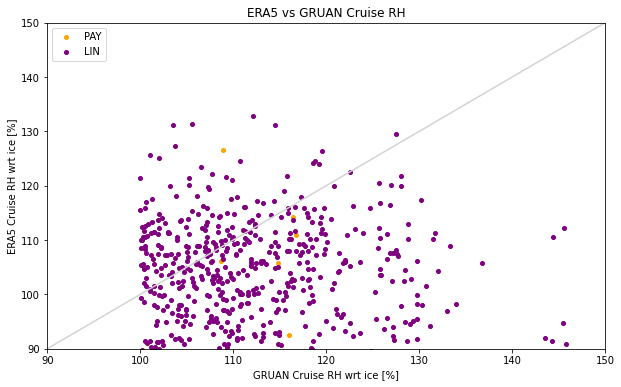

In [9]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name
color_options = ['green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
plt.figure(figsize=(10, 6))
plt.rcParams['figure.dpi'] = 300
j = 0

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    if np.isnan(ERA5_RH[i]):
        print("ERA5 RH is NaN for site", site_name)
        continue
    else:
        if site_name in legend_keys:
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], color=colors[site_name], s = 16)
        else:
            print("New site!", site_name)
            if site_name not in colors:
                j = j+1
                colors[site_name] = color_options[j]  # generate a random color for new site_name
            
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], label=site_name, color=colors[site_name], s = 16)
            legend_keys.add(site_name)
print(colors)
plt.ylim(90,150)
plt.xlim(90,150)
corr_xy = np.linspace(0, len(ERA5_data))
plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN Cruise RH wrt ice [%]')
plt.ylabel('ERA5 Cruise RH wrt ice [%]')
plt.title('ERA5 vs GRUAN Cruise RH')
plt.legend(loc='upper left')  # move the legend to the bottom right
plt.show()


25


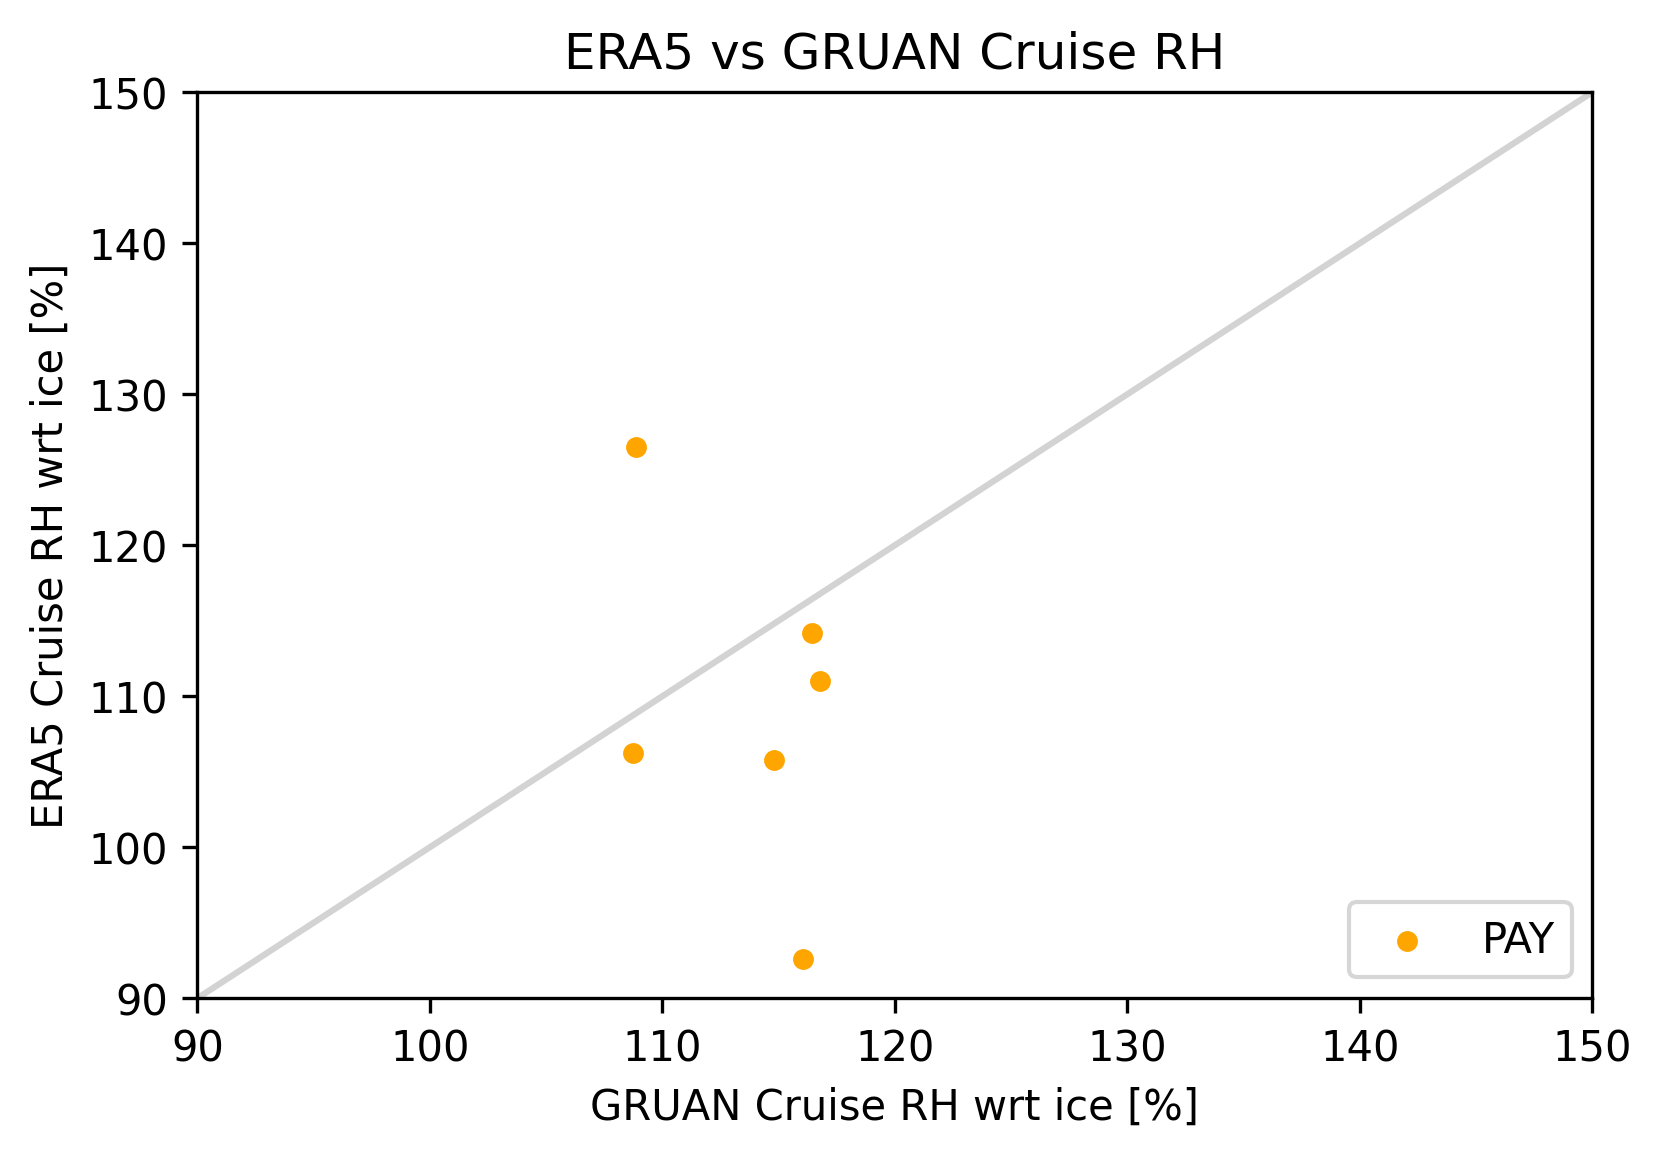

2013


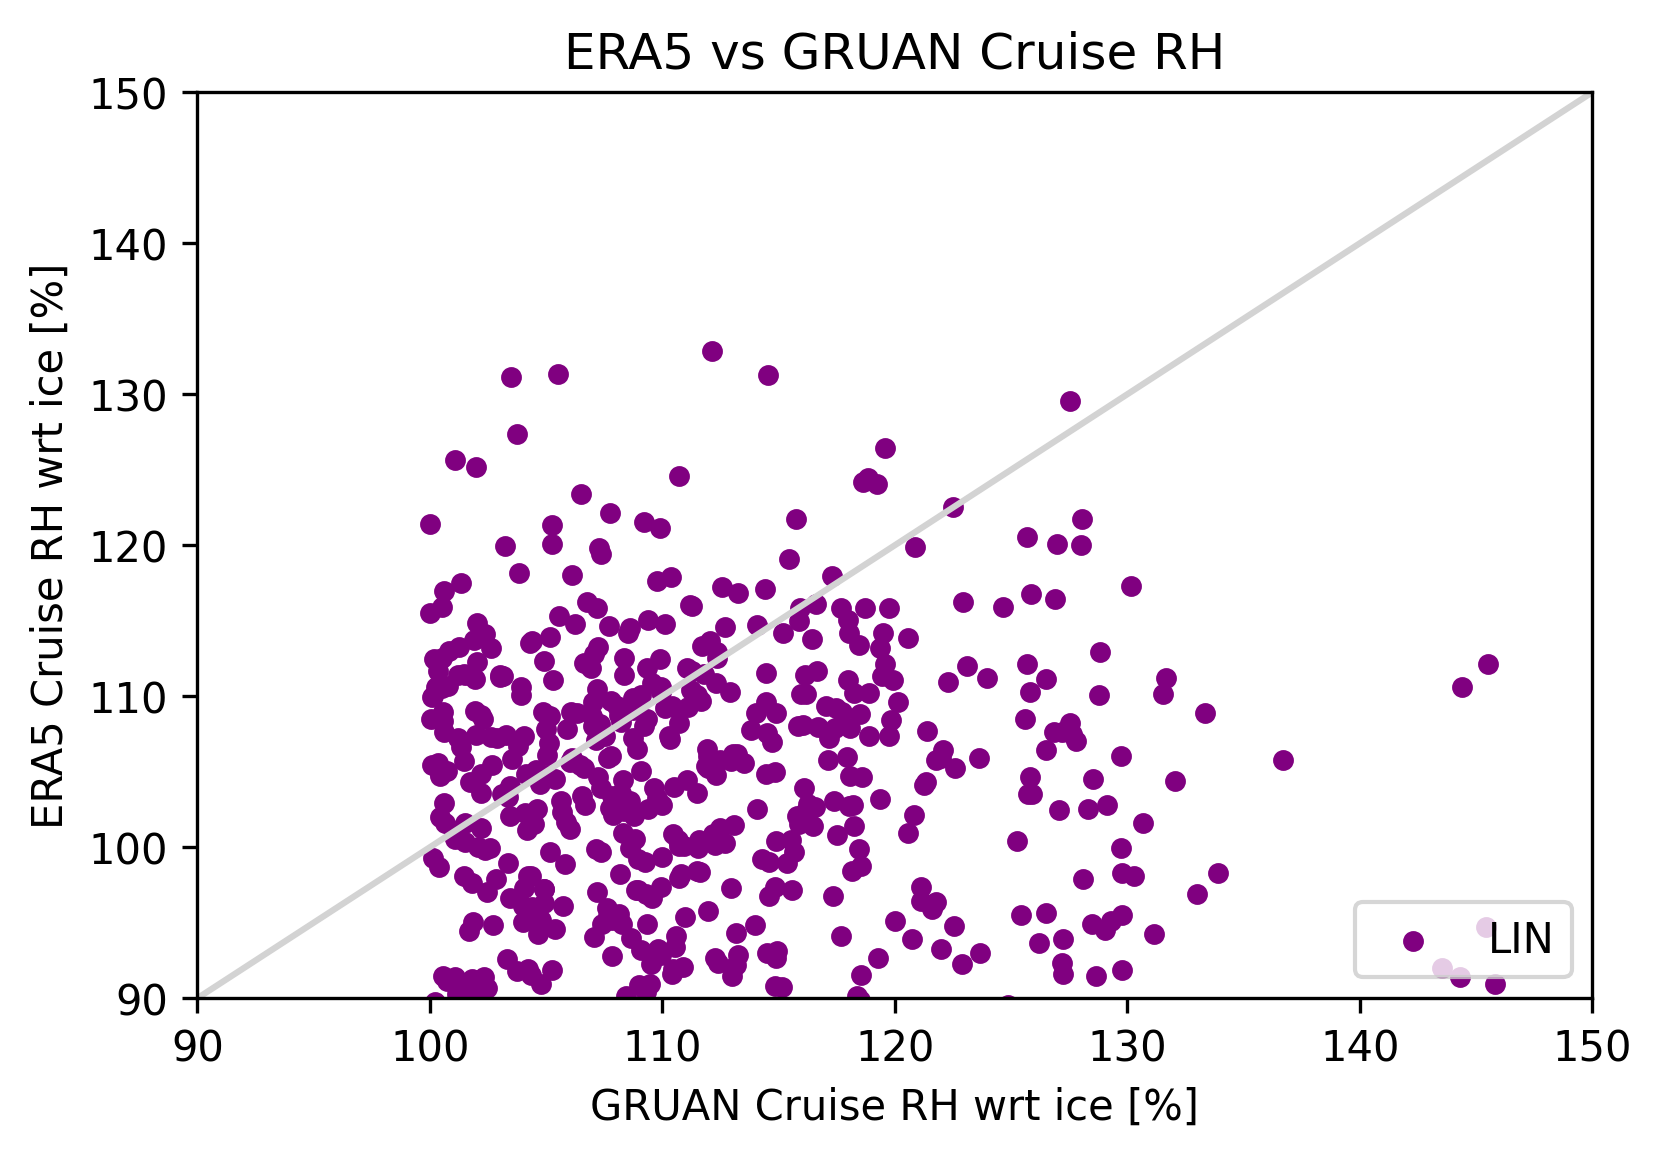

dict_keys(['PAY', 'LIN'])


In [17]:


site_data_dict = {}  # dictionary to store data for each site_name
for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    # Save data for each site_name
    if np.isnan(GRUAN_RH[i]) or np.isnan(ERA5_RH[i]):
        continue
    else:
        site_data = {'GRUAN_RH': GRUAN_RH[i], 'ERA5_RH': ERA5_RH[i]}
    
    if site_name not in site_data_dict:
        site_data_dict[site_name] = []
    site_data_dict[site_name].append(site_data)

# Plot each site_name separately
for site_name, site_data in site_data_dict.items():
    site_data = pd.DataFrame(site_data)
    print(site_data['GRUAN_RH'].size)
    plt.scatter(site_data['GRUAN_RH'], site_data['ERA5_RH'], color = colors[site_name], label=site_name, s = 16)
    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')

    plt.ylim(90,150)
    plt.xlim(90,150)
    corr_xy = np.linspace(0, len(ERA5_data))
    plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')
    plt.legend(loc='lower right')  # move the legend to the bottom right
    plt.show()

print(site_data_dict.keys())

In [11]:
import os

parent_directory = '/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/'
site_directories = ['BEL', 'BOU', 'CAB', 'GRA', 'LIN', 'PAY', 'POT', 'SGP', 'TAT']  # Replace with the actual site directories

for site_directory in site_directories:
    site_path = os.path.join(parent_directory, site_directory)
    file_count = sum(len(files) for _, _, files in os.walk(site_path))
    print(f"Site Directory: {site_directory}, File Count: {file_count}")

Site Directory: BEL, File Count: 268
Site Directory: BOU, File Count: 131
Site Directory: CAB, File Count: 1349
Site Directory: GRA, File Count: 982
Site Directory: LIN, File Count: 12090
Site Directory: PAY, File Count: 185
Site Directory: POT, File Count: 111
Site Directory: SGP, File Count: 7763
Site Directory: TAT, File Count: 1317
649372


In [ ]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    if site_name in legend_keys:
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], color=colors[site_name])
    else:
        if site_name not in colors:
            colors[site_name] = np.random.rand(3,)  # generate a random color for new site_name
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], label=site_name, color=colors[site_name])
        legend_keys.add(site_name)

plt.plot(plt.xlim(), plt.ylim(), color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN MLD [m]')
plt.ylabel('ERA5 MLD [m]')
plt.title('ERA5 vs GRUAN MLD')
plt.legend(loc='lower right')  # move the legend to the bottom right
plt.show()